<a href="https://colab.research.google.com/github/PreranaRaoAdyapady1910/Machine-Learning/blob/main/Lab4(25_08).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#breast cancer wisconsin dataset which has malignant and benign
#preprocessing, build two models, decision tree and linear regression#cm, train accuracy recall f1 score, train precision
#give conclusion on which model is best
#if numerical values-missing->replaced by mean or median, cat missing->mode
#confusion matrix only for testing#dataset, preprocessing, train and test

In [4]:
import pandas as pd
import numpy as np

In [5]:
#Step 1:Load the dataset
df = pd.read_csv('/content/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.shape

(569, 33)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [8]:
df.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [9]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [10]:
df.isnull().sum().sum()

np.int64(569)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [13]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [14]:
df['diagnosis'].value_counts(normalize=True) * 100

,proportion
diagnosis,
B,62.741652
M,37.258348


In [15]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [16]:
df.select_dtypes(include=['object', 'category']).columns

Index(['diagnosis'], dtype='object')

In [17]:
df.select_dtypes(include=['number']).columns

Index(['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [18]:
#Step 2:Data Preprocessing
df = df.drop(columns=['id', 'Unnamed: 32'])
print("Shape after removing irrelevant columns:", df.shape)
print(df.columns.tolist())

Shape after removing irrelevant columns: (569, 31)
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [19]:
print(df.isnull().sum())
print("Total missing values:", df.isnull().sum().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
Total missing values: 0


In [20]:
print(df['diagnosis'].unique())

['M' 'B']


In [21]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [22]:
print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [23]:
#Step 3:Separate Features and Target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y unique values:", y.unique())

X shape: (569, 30)
y shape: (569,)
y unique values: [1 0]


In [24]:
#Step 4:Split Dataset (70% Train, 30% Test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)


In [25]:
#Step 5:Build Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
#Step 6:Decision Tree Predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

In [28]:
#Step 7:Decision Tree Training Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
dt_train_precision = precision_score(y_train, y_train_pred_dt)
dt_train_recall = recall_score(y_train, y_train_pred_dt)
dt_train_f1 = f1_score(y_train, y_train_pred_dt)

print("Decision Tree - Training Metrics")
print("---------------------------------")
print("Train Accuracy :", dt_train_accuracy)
print("Train Precision:", dt_train_precision)
print("Train Recall   :", dt_train_recall)
print("Train F1 Score :", dt_train_f1)

Decision Tree - Training Metrics
---------------------------------
Train Accuracy : 1.0
Train Precision: 1.0
Train Recall   : 1.0
Train F1 Score : 1.0


In [29]:
#Step 8:Decision Tree Testing Metrics
dt_test_accuracy = accuracy_score(y_test, y_test_pred_dt)
dt_test_precision = precision_score(y_test, y_test_pred_dt)
dt_test_recall = recall_score(y_test, y_test_pred_dt)
dt_test_f1 = f1_score(y_test, y_test_pred_dt)
print("Decision Tree - Testing Metrics")
print("--------------------------------")
print("Test Accuracy :", dt_test_accuracy)
print("Test Precision:", dt_test_precision)
print("Test Recall   :", dt_test_recall)
print("Test F1 Score :", dt_test_f1)

Decision Tree - Testing Metrics
--------------------------------
Test Accuracy : 0.9005847953216374
Test Precision: 0.8852459016393442
Test Recall   : 0.84375
Test F1 Score : 0.864


In [54]:
#Step 9:Decision Tree Confusion Matrix
from sklearn.metrics import confusion_matrix
dt_cm = confusion_matrix(y_test, y_test_pred_dt)
print("\nDecision Tree - Confusion Matrix")
print(dt_cm)


Decision Tree - Confusion Matrix
[[100   7]
 [ 10  54]]


In [31]:
print(df['diagnosis'].unique())
print(y_train.unique())
print(y_test.unique())

[1 0]
[1 0]
[0 1]


In [32]:
#Step 10:Scale Data for Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
#Step 11:Build Logistic Regression Model
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
#Step 12:Logistic Regression Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

In [35]:
#Step 13:Logistic Regression Training Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_train_accuracy = accuracy_score(y_train, y_train_pred_lr)
lr_train_precision = precision_score(y_train, y_train_pred_lr)
lr_train_recall = recall_score(y_train, y_train_pred_lr)
lr_train_f1 = f1_score(y_train, y_train_pred_lr)

print("Logistic Regression - Training")
print("---------------------------------------")
print("Train Accuracy :", lr_train_accuracy)
print("Train Precision:", lr_train_precision)
print("Train Recall   :", lr_train_recall)
print("Train F1 Score :", lr_train_f1)


Logistic Regression - Training
---------------------------------------
Train Accuracy : 0.9874371859296482
Train Precision: 1.0
Train Recall   : 0.9662162162162162
Train F1 Score : 0.9828178694158075


In [36]:
#Step 14:Logistic Regression Testing Metrics

lr_test_accuracy = accuracy_score(y_test,y_test_pred_lr)
lr_test_precision = precision_score(y_test,y_test_pred_lr)
lr_test_recall = recall_score(y_test,y_test_pred_lr)
lr_test_f1 = f1_score(y_test,y_test_pred_lr)

print("Logistic Regression - Testing")
print("---------------------------------------")
print("Test Accuracy :",lr_test_accuracy)
print("Test Precision:",lr_test_precision)
print("Test Recall   :",lr_test_recall)
print("Test F1 Score :",lr_test_f1)

Logistic Regression - Testing
---------------------------------------
Test Accuracy : 0.9707602339181286
Test Precision: 0.9836065573770492
Test Recall   : 0.9375
Test F1 Score : 0.96


In [55]:
#Step 15:Logistic Regression  Confusion Matrix
from sklearn.metrics import confusion_matrix
lr_cm = confusion_matrix(y_test, y_test_pred_lr)

print("Logistic Regression - Confusion Matrix")
print(lr_cm)

Logistic Regression - Confusion Matrix
[[106   1]
 [  4  60]]


In [52]:
#Step 16:Training and Testing Model Comparison

results = pd.DataFrame({
    'Model':['Decision Tree','Logistic Regression'],
    'Train Accuracy':[dt_train_accuracy,lr_train_accuracy],
    'Train Precision':[dt_train_precision,lr_train_precision],
    'Train Recall':[dt_train_recall,lr_train_recall],
    'Train F1 Score':[dt_train_f1,lr_train_f1],
    'Test Accuracy':[dt_test_accuracy,lr_test_accuracy],
    'Test Precision':[dt_test_precision,lr_test_precision],
    'Test Recall':[dt_test_recall,lr_test_recall],
    'Test F1 Score':[dt_test_f1,lr_test_f1]
})

results = results.set_index('Model')
results = results.round(4)

print("Training and Testing Model Comparison")
print("="*140)
print(results.to_string())
print("="*140)

Training and Testing Model Comparison
                     Train Accuracy  Train Precision  Train Recall  Train F1 Score  Test Accuracy  Test Precision  Test Recall  Test F1 Score
Model                                                                                                                                        
Decision Tree                1.0000              1.0        1.0000          1.0000         0.9006          0.8852       0.8438          0.864
Logistic Regression          0.9874              1.0        0.9662          0.9828         0.9708          0.9836       0.9375          0.960


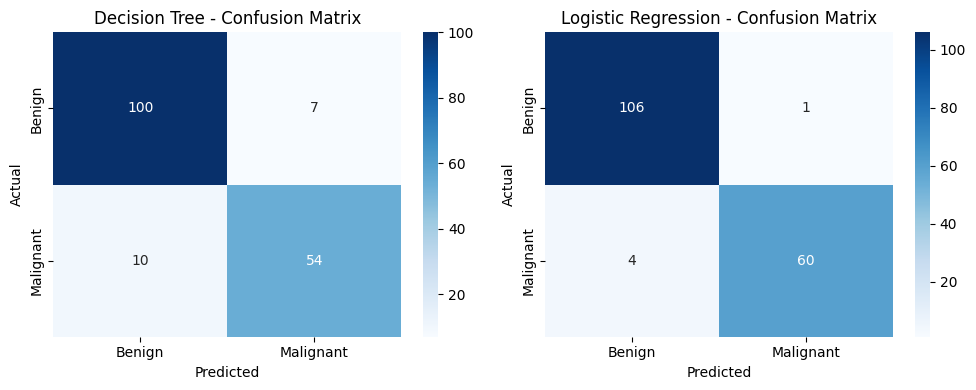

In [49]:
#Step 17:Confusion matrix plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(dt_cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(lr_cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

In [51]:
#Step 18:Final Conclusion

print("\n========== FINAL MODEL COMPARISON ==========")
print(f"{'Metric':<12}{'Decision Tree':<18}{'Logistic Regression':<20}")
print("-"*50)
print(f"{'Accuracy':<12}{dt_test_accuracy:<18.4f}{lr_test_accuracy:<20.4f}")
print(f"{'Precision':<12}{dt_test_precision:<18.4f}{lr_test_precision:<20.4f}")
print(f"{'Recall':<12}{dt_test_recall:<18.4f}{lr_test_recall:<20.4f}")
print(f"{'F1 Score':<12}{dt_test_f1:<18.4f}{lr_test_f1:<20.4f}")

if lr_test_f1 > dt_test_f1:
    print("\nConclusion: Logistic Regression is the better model.")
else:
    print("\nConclusion: Decision Tree is the better model.")



========== FINAL MODEL COMPARISON ==========
Metric      Decision Tree     Logistic Regression 
--------------------------------------------------
Accuracy    0.9006            0.9708              
Precision   0.8852            0.9836              
Recall      0.8438            0.9375              
F1 Score    0.8640            0.9600              

Conclusion: Logistic Regression is the better model.
